In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#ignore warning
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.pairwise import euclidean_distances
import plotly.express as px
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import pickle
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

In [21]:
def load_and_preprocess_data(file_path):

    df = pd.read_csv(file_path)
    # Convert 'InvoiceNo' to string to avoid issues with mixed types
    df['InvoiceNo'] = df['InvoiceNo'].astype(str)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    return df
df = load_and_preprocess_data('Online Retail.csv')

In [22]:
df.head(6)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom


In [23]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [24]:
df.info()
#description và customerid có Nan cần xử lí

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [25]:
#locate where customerid is null
df[df['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [26]:
#locate where description is nan
df[df['Description'].isnull()]
#nếu description là nan thì chúng ta không biết khách hàng mua gì khi UnitPrice = 0
#dropnan description

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [27]:
for col in df['Description'].unique():
    print(col)
#nhiều mục sai (mixed up, lost, missing, ???? need, gift, test, sample, damaged, error)
# Cùng tìm hiểu nó là gì nào

WHITE HANGING HEART T-LIGHT HOLDER
WHITE METAL LANTERN
CREAM CUPID HEARTS COAT HANGER
KNITTED UNION FLAG HOT WATER BOTTLE
RED WOOLLY HOTTIE WHITE HEART.
SET 7 BABUSHKA NESTING BOXES
GLASS STAR FROSTED T-LIGHT HOLDER
HAND WARMER UNION JACK
HAND WARMER RED POLKA DOT
ASSORTED COLOUR BIRD ORNAMENT
POPPY'S PLAYHOUSE BEDROOM 
POPPY'S PLAYHOUSE KITCHEN
FELTCRAFT PRINCESS CHARLOTTE DOLL
IVORY KNITTED MUG COSY 
BOX OF 6 ASSORTED COLOUR TEASPOONS
BOX OF VINTAGE JIGSAW BLOCKS 
BOX OF VINTAGE ALPHABET BLOCKS
HOME BUILDING BLOCK WORD
LOVE BUILDING BLOCK WORD
RECIPE BOX WITH METAL HEART
DOORMAT NEW ENGLAND
JAM MAKING SET WITH JARS
RED COAT RACK PARIS FASHION
YELLOW COAT RACK PARIS FASHION
BLUE COAT RACK PARIS FASHION
BATH BUILDING BLOCK WORD
ALARM CLOCK BAKELIKE PINK
ALARM CLOCK BAKELIKE RED 
ALARM CLOCK BAKELIKE GREEN
PANDA AND BUNNIES STICKER SHEET
STARS GIFT TAPE 
INFLATABLE POLITICAL GLOBE 
VINTAGE HEADS AND TAILS CARD GAME 
SET/2 RED RETROSPOT TEA TOWELS 
ROUND SNACK BOXES SET OF4 WOODLAND 
SPA

In [28]:
df = df.dropna(subset=['Description'])

In [29]:

#find not normal 6 digits invoice
df[df['InvoiceNo'].str.match('^\d{6}$') == False]
#ALl non-6 digits invoice have C before their No
# Chúng ta thấy các customer này thường có quantity là âm, hãy kiểm tra nó xem
 #C must be Cancel customer

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [30]:
Damage_customers = df[df['InvoiceNo'].str.match('^\d{6}$') == True & (df['Quantity'] < 0)]
# Damage_customers['Description'].unique().tolist()
# Description đều báo lỗi chứng tỏ các các khách hàng này là Damages/Stock Corrections

In [31]:
Cancel_customers = df[df['InvoiceNo'].str.match('^\d{6}$') == False & (df['Quantity'] < 0)]
# Cancel_customers
#Description bình thường chứng tỏ đây là nhóm rời bỏ Churn
#Sau khi phân cụm xong nhóm này sẽ là Cancel

In [32]:
df[df['UnitPrice'] < 0]
#Unit price < 0 is simply wrong value we will drop it
# A này có thể là khách hàng bị đuổi vì nợ xấu
# 2 dòng này sẽ bị loại khỏi bài đến cuối cùng luôn

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [33]:
df.dropna(subset=['CustomerID'], inplace=True)

In [34]:
#lấy df khi quantity và unitprce >0
data = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [35]:
for col in data['Description'].unique():
    print(col)
#các mục sai đã hết sau khi drop quantity < 0

WHITE HANGING HEART T-LIGHT HOLDER
WHITE METAL LANTERN
CREAM CUPID HEARTS COAT HANGER
KNITTED UNION FLAG HOT WATER BOTTLE
RED WOOLLY HOTTIE WHITE HEART.
SET 7 BABUSHKA NESTING BOXES
GLASS STAR FROSTED T-LIGHT HOLDER
HAND WARMER UNION JACK
HAND WARMER RED POLKA DOT
ASSORTED COLOUR BIRD ORNAMENT
POPPY'S PLAYHOUSE BEDROOM 
POPPY'S PLAYHOUSE KITCHEN
FELTCRAFT PRINCESS CHARLOTTE DOLL
IVORY KNITTED MUG COSY 
BOX OF 6 ASSORTED COLOUR TEASPOONS
BOX OF VINTAGE JIGSAW BLOCKS 
BOX OF VINTAGE ALPHABET BLOCKS
HOME BUILDING BLOCK WORD
LOVE BUILDING BLOCK WORD
RECIPE BOX WITH METAL HEART
DOORMAT NEW ENGLAND
JAM MAKING SET WITH JARS
RED COAT RACK PARIS FASHION
YELLOW COAT RACK PARIS FASHION
BLUE COAT RACK PARIS FASHION
BATH BUILDING BLOCK WORD
ALARM CLOCK BAKELIKE PINK
ALARM CLOCK BAKELIKE RED 
ALARM CLOCK BAKELIKE GREEN
PANDA AND BUNNIES STICKER SHEET
STARS GIFT TAPE 
INFLATABLE POLITICAL GLOBE 
VINTAGE HEADS AND TAILS CARD GAME 
SET/2 RED RETROSPOT TEA TOWELS 
ROUND SNACK BOXES SET OF4 WOODLAND 
SPA

In [36]:
# Số cột mà sau khi grouby sẽ có
data['CustomerID'].nunique()

4338

In [37]:
def calculate_total_price(data):
    data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
    return data
data = calculate_total_price(data)
data.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [38]:
import datetime as dt
def create_rfm_features(df):
    snapshot_date = data['InvoiceDate'].max() + dt.timedelta(days=1)

    # RFM
    rfm = data.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,           # Recency
        'InvoiceNo': 'nunique',         # Frequency
        'TotalPrice': 'sum'             # Monetary
    }).reset_index()

    rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
    return rfm

rfm = create_rfm_features(data)
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [39]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   float64
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB


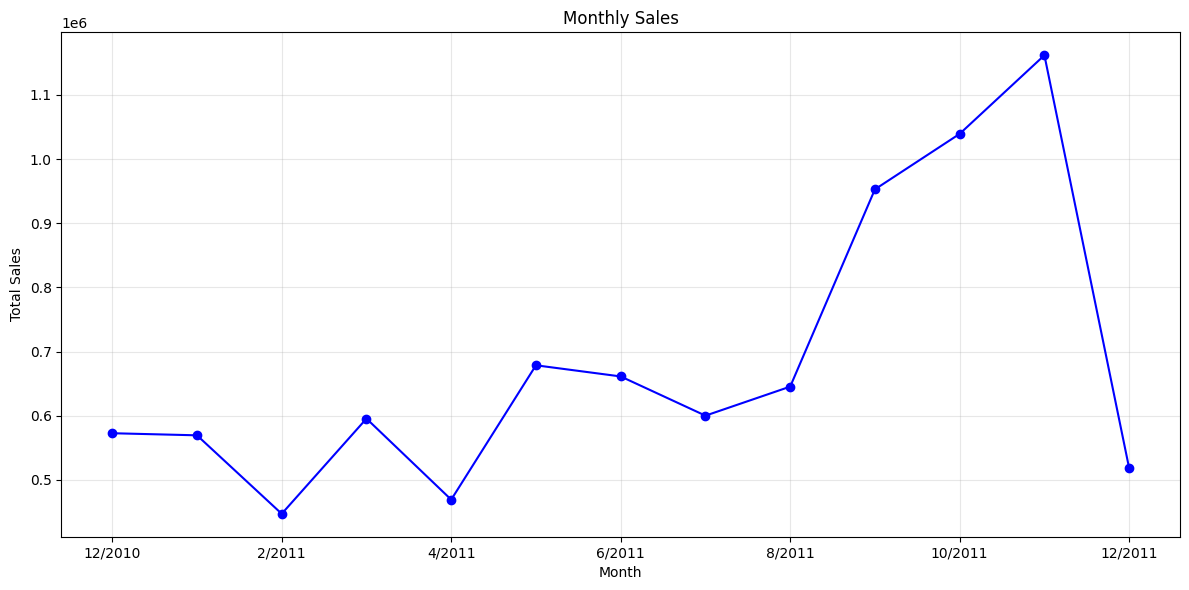

In [40]:
plt.figure(figsize=(12, 6))
monthly_sales = data.set_index('InvoiceDate').resample('M')['TotalPrice'].sum()

# Plot with month numbers
plt.plot(range(len(monthly_sales)), monthly_sales.values, marker='o' , color = 'blue')

# Show every other month label
plt.xticks(range(0, len(monthly_sales), 2),
[f'{date.month}/{date.year}' for date in monthly_sales.index][::2])

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


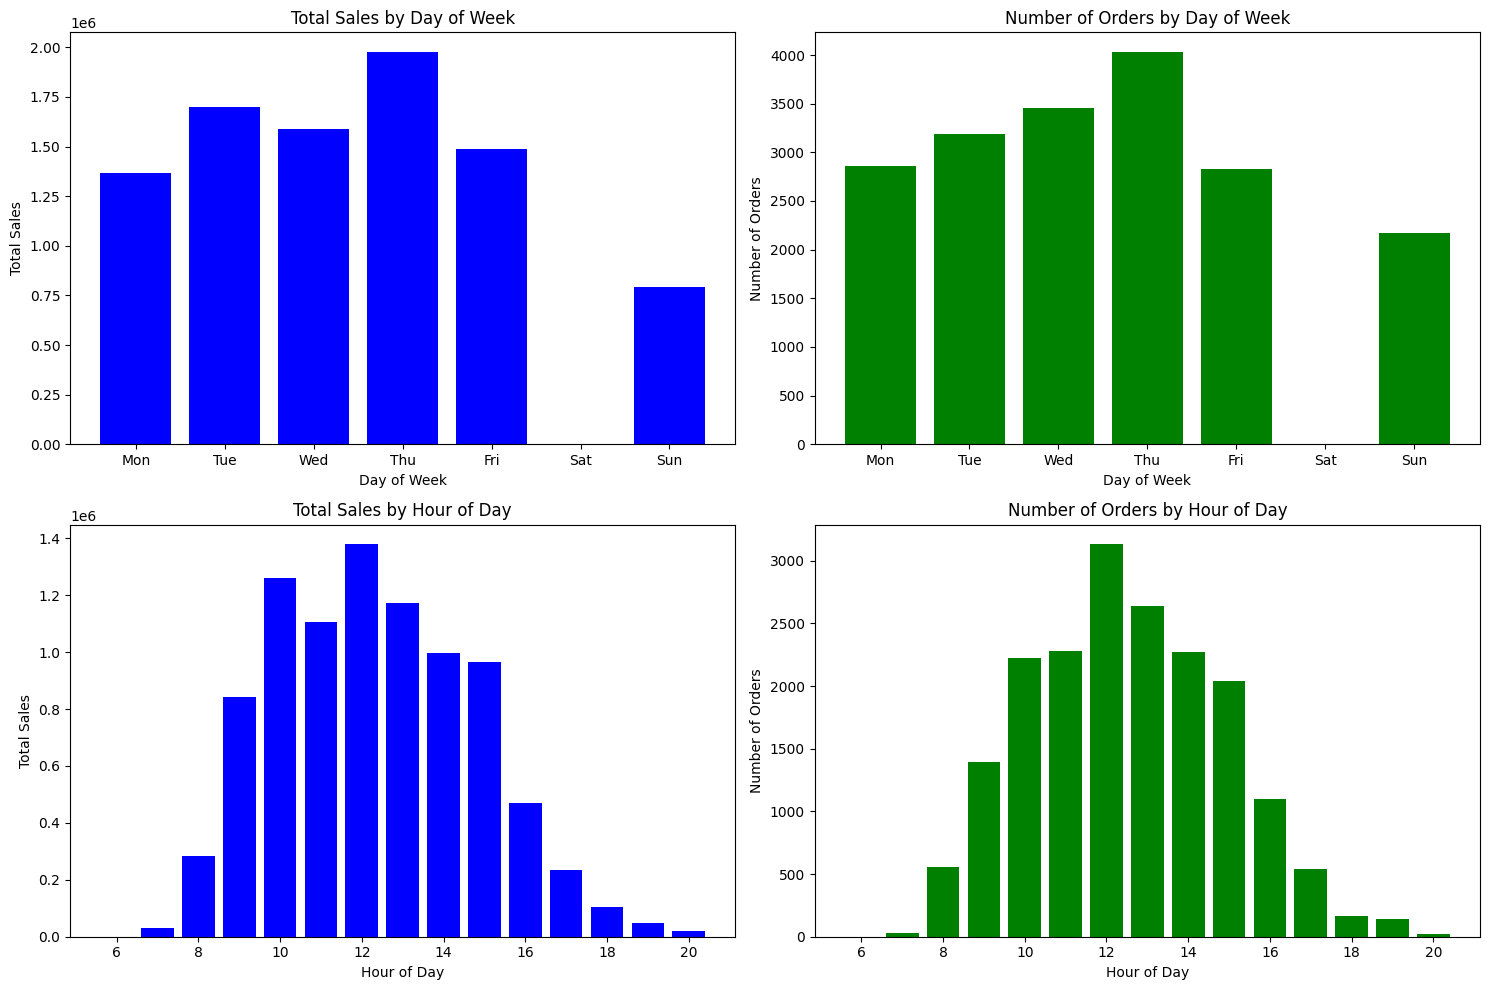

In [41]:
data['DayOfWeek'] = data['InvoiceDate'].dt.dayofweek  # Monday=0, Sunday=6
data['HourOfDay'] = data['InvoiceDate'].dt.hour

dayofweek_sales = data.groupby('DayOfWeek')['TotalPrice'].sum()
dayofweek_orders = data.groupby('DayOfWeek')['InvoiceNo'].nunique()
hourofday_sales = data.groupby('HourOfDay')['TotalPrice'].sum()
hourofday_orders = data.groupby('HourOfDay')['InvoiceNo'].nunique()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot Total Sales by Day of Week
axes[0, 0].bar(dayofweek_sales.index, dayofweek_sales.values, color = 'blue')
axes[0, 0].set_title('Total Sales by Day of Week')
axes[0, 0].set_xlabel('Day of Week')
axes[0, 0].set_ylabel('Total Sales')
axes[0, 0].set_xticks(range(7)) # Set ticks for all 7 days
axes[0, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])


# Plot Number of Orders by Day of Week
axes[0, 1].bar(dayofweek_orders.index, dayofweek_orders.values, color = 'green')
axes[0, 1].set_title('Number of Orders by Day of Week')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Number of Orders')
axes[0, 1].set_xticks(range(7)) # Set ticks for all 7 days
axes[0, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# Plot Total Sales by Hour of Day
axes[1, 0].bar(hourofday_sales.index, hourofday_sales.values, color='blue')
axes[1, 0].set_title('Total Sales by Hour of Day')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Total Sales')


# Plot Number of Orders by Hour of Day
axes[1, 1].bar(hourofday_orders.index, hourofday_orders.values, color = 'green')
axes[1, 1].set_title('Number of Orders by Hour of Day')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Number of Orders')


plt.tight_layout()
plt.show()

In [42]:

def plot_top_countries(data, grp ,col, n):
    country_sales = data.groupby(grp)[col].sum().sort_values(ascending=False)
    top_countries = country_sales.head(n)

    total_sales_top_countries = country_sales.sum()
    percentage_contribution = (top_countries / total_sales_top_countries) * 100

    colors = ['lightgreen', 'red', 'blue', 'orange', 'purple']

    ax = percentage_contribution.plot(kind='barh', color=colors)
    plt.title(f'Top 5 by {grp} Percentage Contribution to {col}')
    plt.xlabel(f'Percentage Contribution to {col}')
    plt.ylabel(f'{grp}')
    plt.grid()

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')
    plt.show()

def plot_least(data, grp ,col, n):
    country_sales = data.groupby(grp)[col].sum().sort_values(ascending=True)
    top_countries = country_sales.head(n)

    total_sales_top_countries = country_sales.sum()
    percentage_contribution = (top_countries / total_sales_top_countries) * 100

    colors = ['lightgreen', 'red', 'blue', 'orange', 'purple']

    ax = percentage_contribution.plot(kind='barh', color=colors)
    plt.title(f'Top 5 by {grp} Percentage Contribution to {col}')
    plt.xlabel(f'Percentage Contribution to {col}')
    plt.ylabel(f'{grp}')
    plt.grid()

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')
    plt.show()

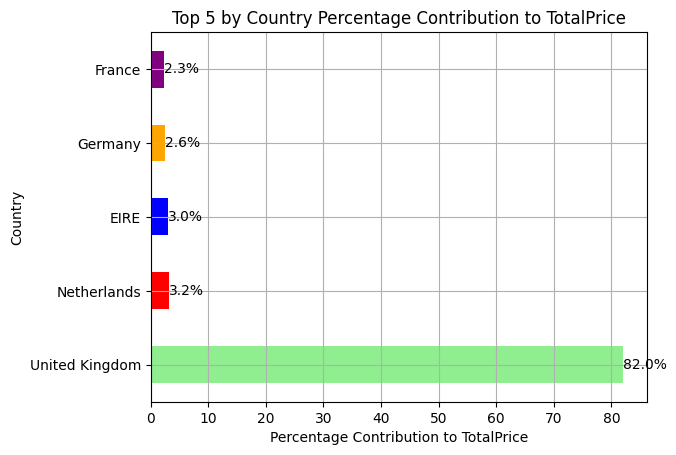

In [43]:
# PLOTTING PERCENTAGE ON GRAPH TO SHOW HOW MUCH DIFFERENT COUNTRIES CONTRIBUTE TO THE SALES
plot_top_countries(data, 'Country','TotalPrice', 5)

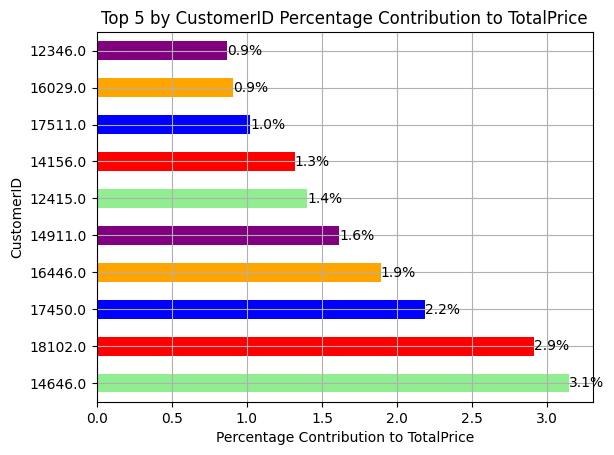

In [44]:
# PLOT TO SEE 10 BEST CUSTOMERS OF THE STORES
plot_top_countries(data, 'CustomerID','TotalPrice', 10)


Top 10 Most Sold Products (by Quantity):
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


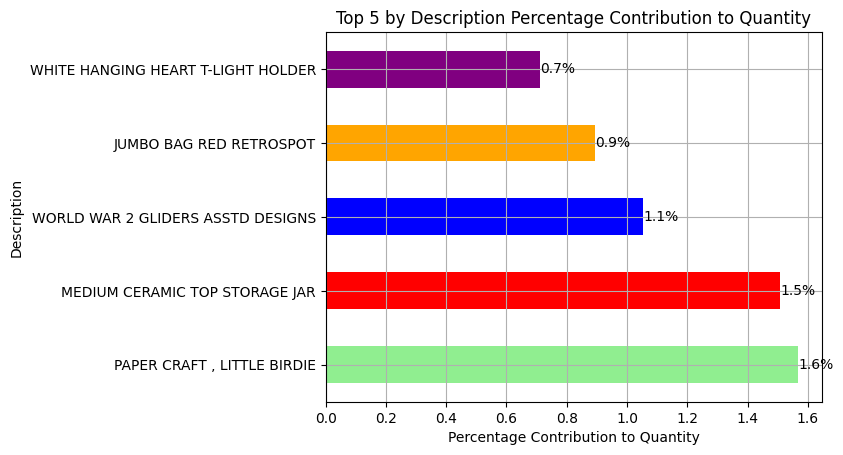


Top 10 Most Sold Products (by Total Price):
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalPrice, dtype: float64


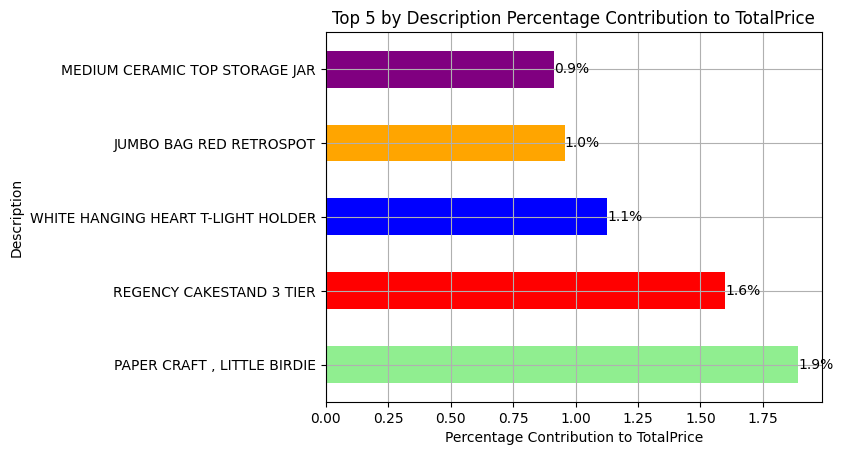

In [45]:
# Identify top 10 most sold products by quantity
top_selling_products_quantity = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print("Top 10 Most Sold Products (by Quantity):")
print(top_selling_products_quantity)

# PLOT TO SEE THE 5 BEST PRODUCTS
plot_top_countries(data, 'Description','Quantity', 5)

# Identify top 10 most sold products by total price
top_selling_products_price = data.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Most Sold Products (by Total Price):")
print(top_selling_products_price)


plot_top_countries(data, 'Description','TotalPrice', 5)


### 2.3.2 Sản phẩm kẹm chạy (Least Products)

In [46]:
# Identify 10 least sold products by quantity
least_selling_products_quantity = data.groupby('Description')['Quantity'].sum().sort_values(ascending=True).head(5)

print("\n10 Least Sold Products (by Quantity):")
print(least_selling_products_quantity)
# Insight: Có nhiều sản phẩm chỉ bán được số lượng rất ít (chỉ 1 sản phẩm), có thể cần xem xét lại việc duy trì các mặt hàng này trong kho.

# plot_least(data, 'Description','Quantity', 5)

# Identify 10 least sold products by total price
least_selling_products_price = data.groupby('Description')['TotalPrice'].sum().sort_values(ascending=True).head(5)

print("\n10 Least Sold Products (by Total Price):")
print(least_selling_products_price)
# Insight: Một số sản phẩm có tổng doanh thu rất thấp, thậm chí gần bằng 0, điều này có thể là do giá trị đơn vị thấp hoặc số lượng bán ra không đáng kể.

# plot_least(data, 'Description','TotalPrice', 5)


10 Least Sold Products (by Quantity):
Description
 I LOVE LONDON MINI RUCKSACK         1
VINTAGE BEAD PINK JEWEL STAND        1
AMBER BERTIE GLASS BEAD BAG CHARM    1
HEN HOUSE W CHICK IN NEST            1
CHERRY BLOSSOM PURSE                 1
Name: Quantity, dtype: int64

10 Least Sold Products (by Total Price):
Description
PADS TO MATCH ALL CUSHIONS         0.003
HEN HOUSE W CHICK IN NEST          0.420
SET 12 COLOURING PENCILS DOILEY    0.650
VINTAGE BLUE TINSEL REEL           0.840
PINK CRYSTAL GUITAR PHONE CHARM    0.850
Name: TotalPrice, dtype: float64


In [47]:
# Analyze cancelled orders
cancelled_orders = df[df['InvoiceNo'].str.contains('C', na=False)]

print("Number of cancelled orders:", len(cancelled_orders))
print("\nSample of cancelled orders:")
display(cancelled_orders.head())

# Phân tích tác động của việc hủy đơn hàng lên tổng doanh số (tùy vào việc mình định nghĩa tác động này là gì)
# Vd có thể so sánh tổng doanh số trước và sau khi xóa các đơn hàng đã hủy

Number of cancelled orders: 8905

Sample of cancelled orders:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
# plt.figure(figsize=(10, 6))
# plt.hist(customer_last_purchase, bins=50, edgecolor='black')
# plt.axvline(x=150, color='red', linestyle='--', label='150 Day Threshold')
# plt.title('Distribution of Days Since Last Purchase')
# plt.xlabel('Days Since Last Purchase')
# plt.ylabel('Number of Customers')
# plt.legend()
# plt.grid(axis='y', alpha=0.75)
# plt.show()

In [50]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

In [51]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


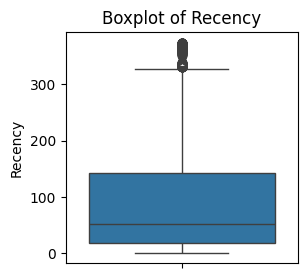

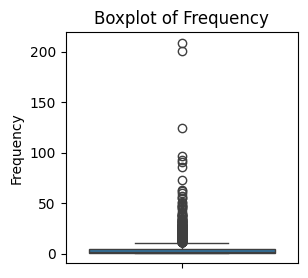

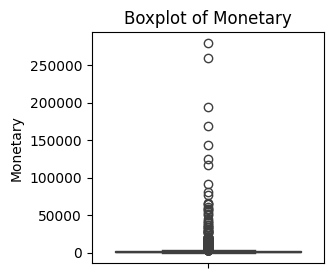

In [52]:
# Plotting boxplots for R, F, M
def plot_boxplot(column, data):
    plt.figure(figsize=(3, 3))
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot of {column}')
    #plt.ylim(lower_bound - 10, upper_bound + 10)
    plt.show()

for col in ['Recency', 'Frequency', 'Monetary']:
    plot_boxplot(col, rfm)

# R không nhiều outlier
# F, M có nhiều outlier cần bỏ đi để tiến hành phân cụm
# -3 : Nhóm có outlier F nhưng ko có M
# -2: Nhóm có outlier M nhưng ko có F
# -1: Nhóm có cả 2 outlier

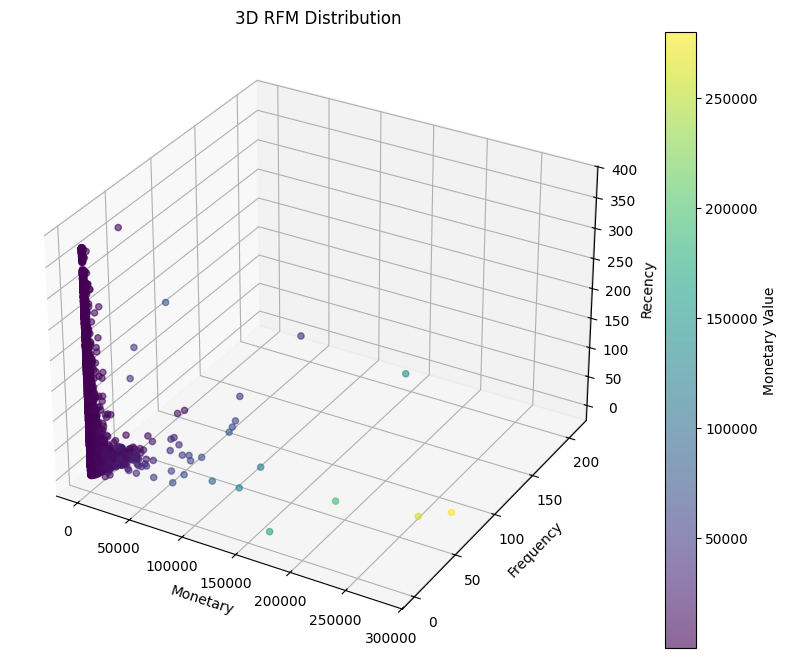

In [53]:
def plot_3d_rfm(df):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(df['Monetary'],
                        df['Frequency'],
                        df['Recency'],
                        c=df['Monetary'],
                        cmap='viridis',
                        alpha=0.6)

    ax.set_xlabel('Monetary')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Recency')

    plt.colorbar(scatter, label='Monetary Value')
    plt.title('3D RFM Distribution')
    plt.show()

plot_3d_rfm(rfm)
# Có quá nhiều outlier cần phải được xử lí

In [54]:
#function for only outliers
def outlier_dataframe(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[col] < lower_bound) | (data[col] > upper_bound)]

#function for only non outliers
def non_outlier_dataframe(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]

f_outliers = outlier_dataframe(rfm, 'Frequency')
m_outliers = outlier_dataframe(rfm, 'Monetary')

f_non_outliers = non_outlier_dataframe(rfm['Frequency'])
m_non_outliers = non_outlier_dataframe(rfm['Monetary'])

In [55]:
#put a non_outliers_df of what index is in f_non_outliers and m_non_outliers
non_outliers_df = rfm[rfm['Frequency'].isin(f_non_outliers) & rfm['Monetary'].isin(m_non_outliers)]
non_outliers_data = non_outliers_df.copy()

In [56]:
non_outliers_df.drop(columns=[ 'CustomerID'], inplace=True)

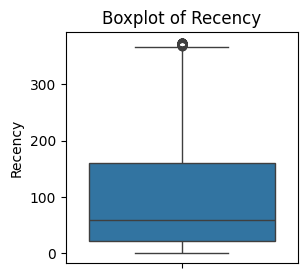

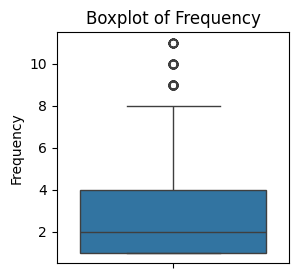

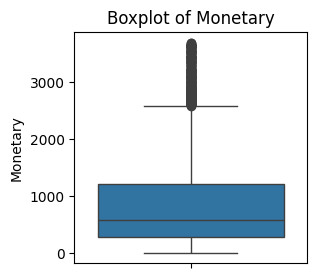

In [57]:
for col in ['Recency', 'Frequency', 'Monetary']:
    plot_boxplot(col, non_outliers_df)
#các box mới đã đỡ xẹp hơn

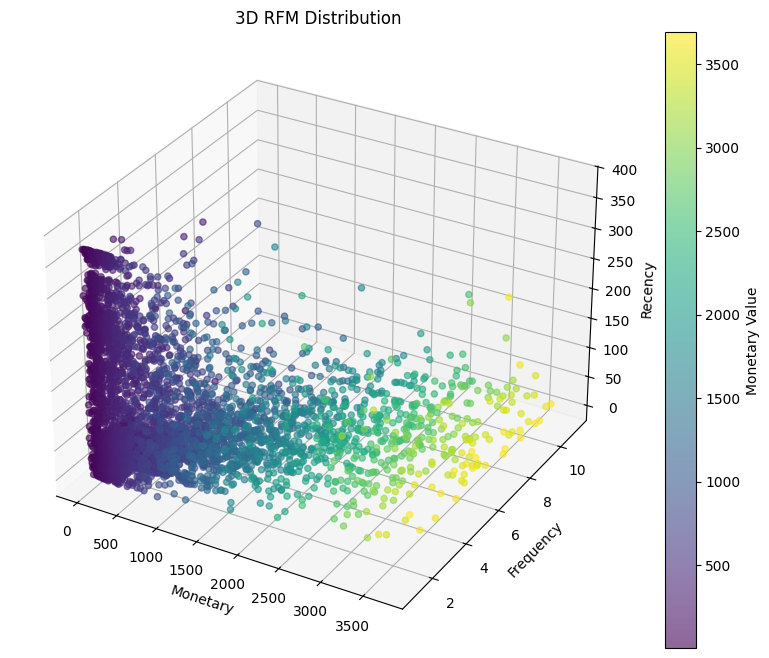

In [58]:
plot_3d_rfm(non_outliers_df)

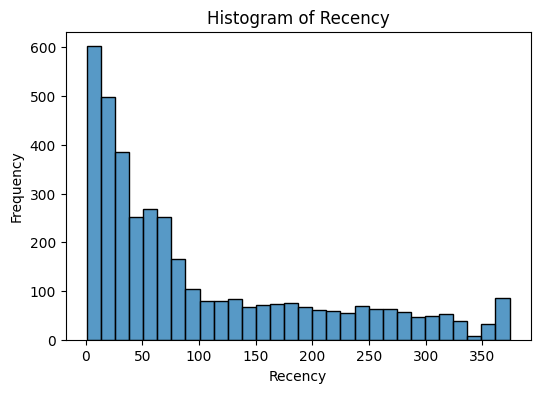

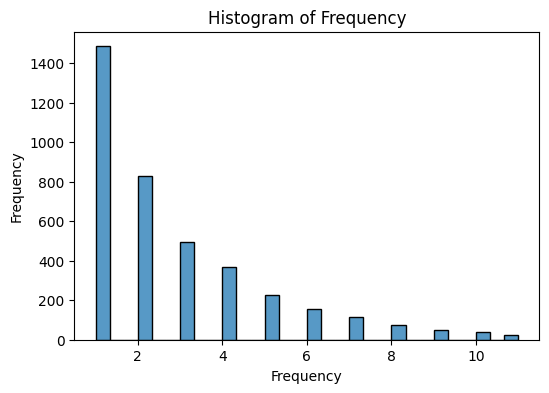

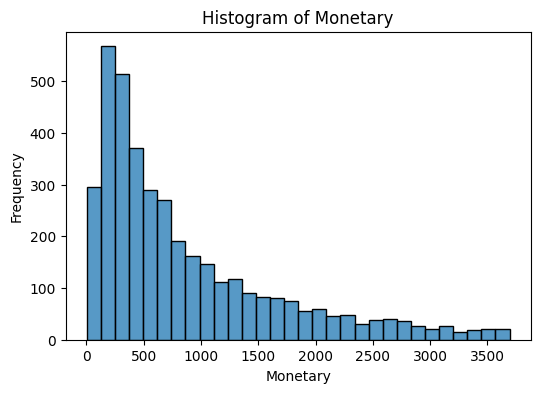

In [59]:
#plot histogram non_outliers_df
for col in non_outliers_df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(non_outliers_df[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

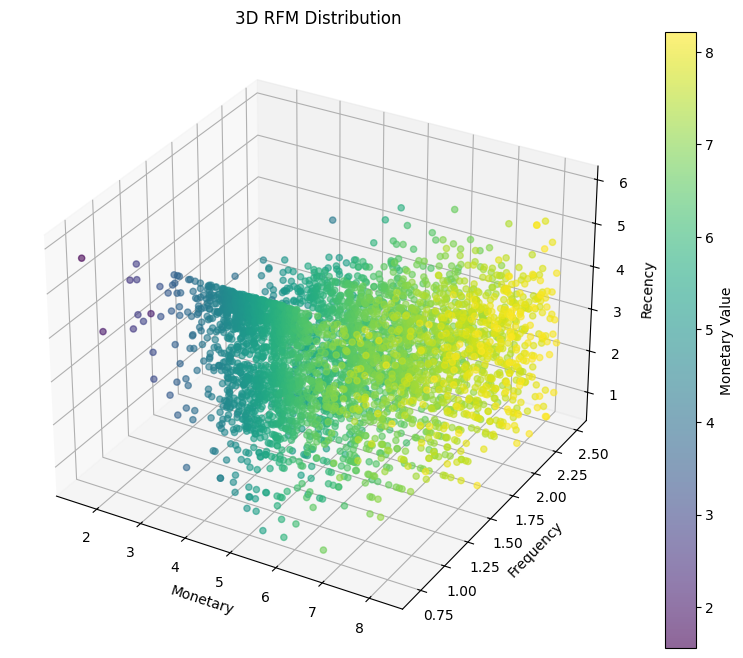

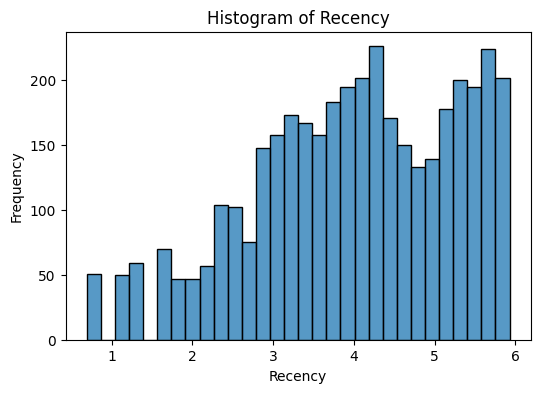

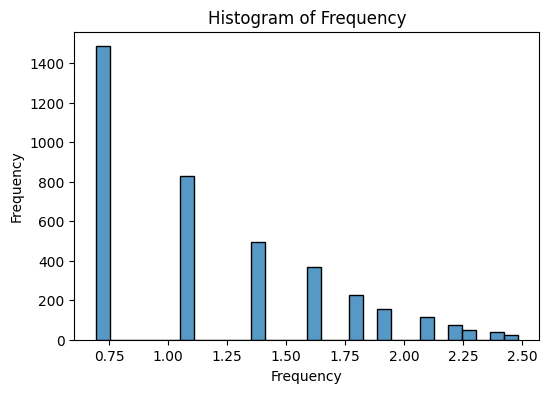

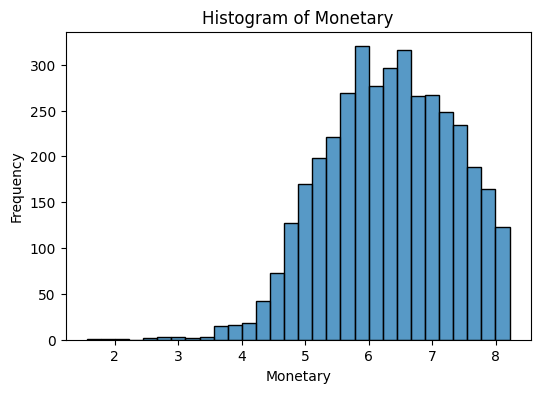

In [60]:
def log_transform(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df_log = df.copy()
    df_log[numeric_cols] = np.log1p(df_log[numeric_cols])
    return df_log

non_outliers_df_log = log_transform(non_outliers_df)

plot_3d_rfm(non_outliers_df_log)

for col in non_outliers_df_log.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(non_outliers_df_log[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [61]:
def standard_scale(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df

standard_scale(non_outliers_df_log)

standard_scale(non_outliers_df)

standard_scale(rfm)

,CustomerID,Recency,Frequency,Monetary
0,-1.716073,2.334574,-0.425097,8.358668
1,-1.715492,-0.905340,0.354417,0.250966
2,-1.714911,-0.175360,-0.035340,-0.028596
3,-1.714330,-0.735345,-0.425097,-0.033012
4,-1.713749,2.174578,-0.425097,-0.191347
...,...,...,...,...
4333,1.730701,1.854587,-0.425097,-0.208459
4334,1.731282,0.884612,-0.425097,-0.219560
4335,1.731863,-0.845342,-0.295178,-0.208742
4336,1.732443,-0.885341,1.523687,0.004519


### 3.1.2 Min Max Scaler

In [62]:
# def min_max_scale(df):
#     numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
#     scaler = MinMaxScaler()
#     df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
#     return df

# min_max_scale(non_outliers_df_log)

# min_max_scale(non_outliers_df)

# min_max_scale(rfm)
# rfm.drop(columns = 'CustomerID', inplace = True, axis = 1)

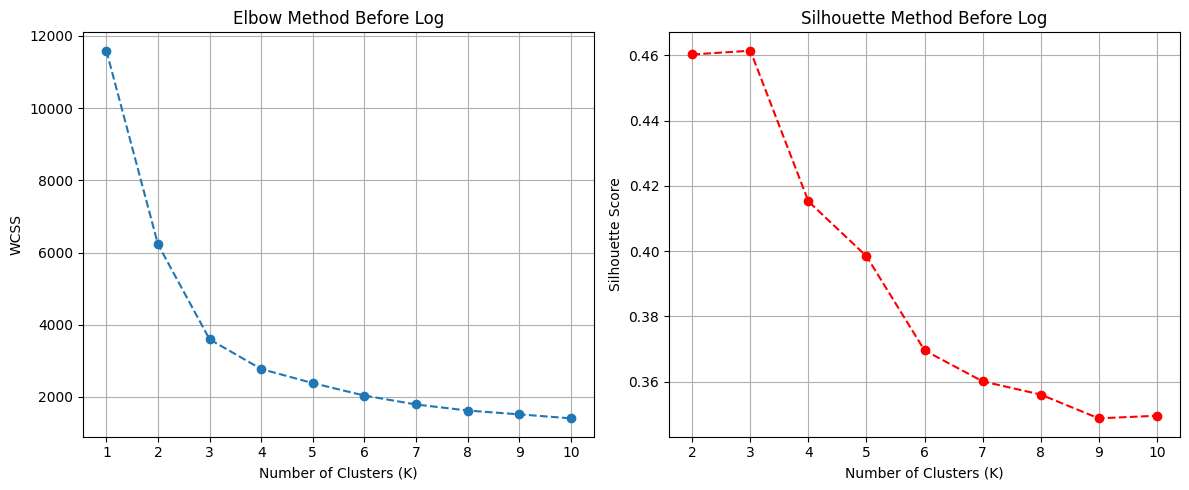

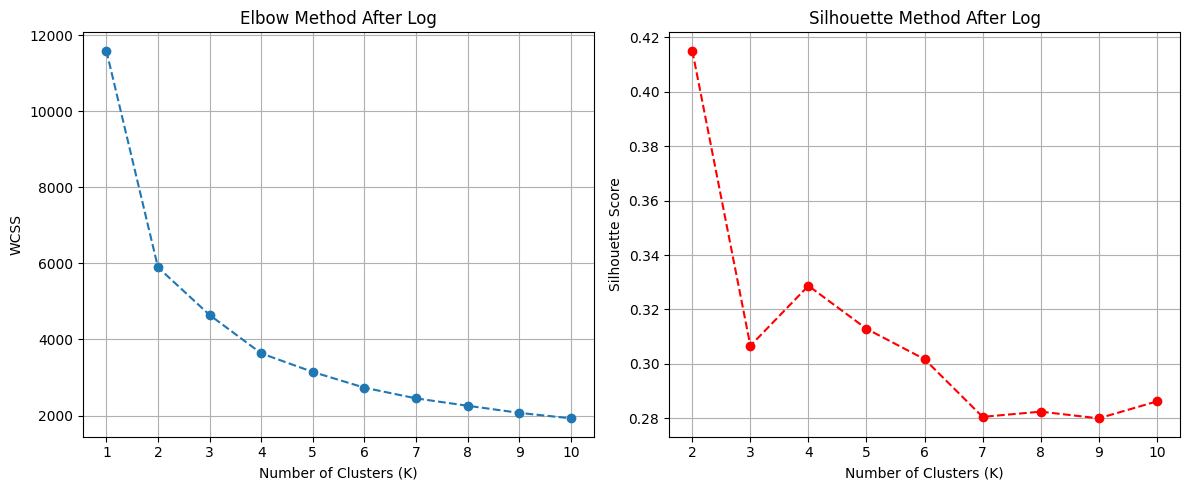

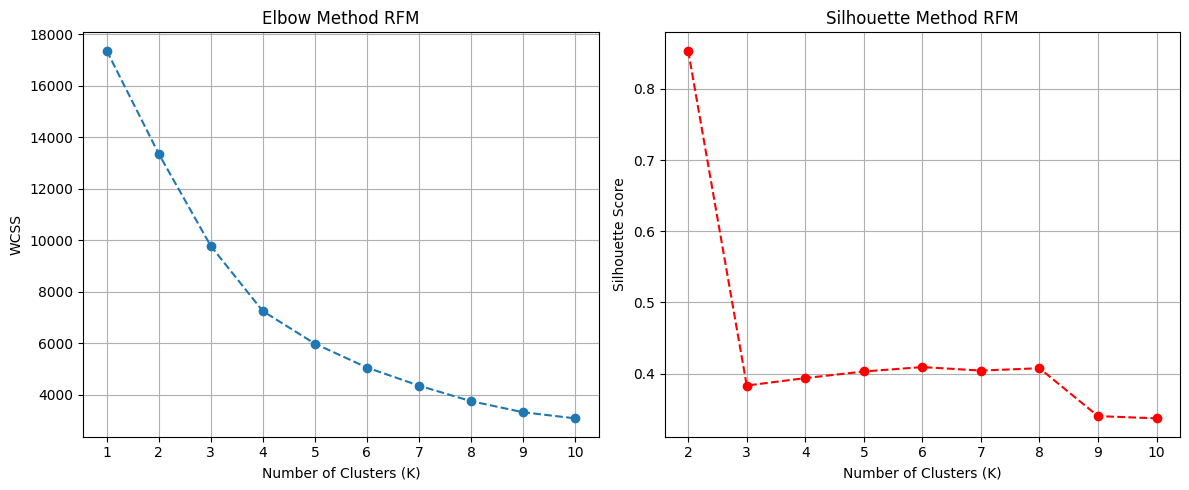

In [63]:
#Đơn thuần là gán giá trị để đặt tên phân biệt, không gọi hàm
non_outliers_df.name = 'Before Log'
non_outliers_df_log.name = 'After Log'
rfm.name = "RFM"
def find_optimal_k_wcss(data, max_k):
    wcss = []
    for i in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)

    # Plot WCSS
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
    plt.title(f'Elbow Method {data.name}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('WCSS')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)

    # Calculate silhouette scores
    silhouette_scores = []
    for i in range(2, max_k + 1):  # Silhouette score needs at least 2 clusters
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        silhouette_scores.append(silhouette_score(data, labels))

    # Plot Silhouette scores
    plt.subplot(1, 2, 2)
    plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', linestyle='--', color = 'red')
    plt.title(f'Silhouette Method {data.name}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.xticks(range(2, max_k + 1))
    plt.grid(True)
    plt.tight_layout()

# Example usage (replace non_outliers_df_log with your data)
# You might want to experiment with different max_k values
find_optimal_k_wcss(non_outliers_df, 10)

find_optimal_k_wcss(non_outliers_df_log, 10)

find_optimal_k_wcss(rfm, 10)

# Silhouette accuracy after Log is significantly lower than before log -> Choose Before log
# choosing k=3

In [64]:
def perform_kmeans_clustering(data, n_clusters):
    # Model
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(data)
    labels = kmeans.labels_

    #3 basic index
    silhouette = silhouette_score(data, labels)
    calinski = calinski_harabasz_score(data, labels)
    davies = davies_bouldin_score(data, labels)

    # Dunn Index
    distances = euclidean_distances(data)

    ## Max intra-cluster distance (diameter)
    max_intra = 0
    for cluster in np.unique(labels):
        cluster_idx = np.where(labels == cluster)[0]
        if len(cluster_idx) > 1:
            intra_dist = distances[np.ix_(cluster_idx, cluster_idx)].max()
            max_intra = max(max_intra, intra_dist)

    ## Min inter-cluster distance
    min_inter = np.inf
    unique_labels = np.unique(labels)
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            cluster_i_idx = np.where(labels == unique_labels[i])[0]
            cluster_j_idx = np.where(labels == unique_labels[j])[0]
            inter_dist = distances[np.ix_(cluster_i_idx, cluster_j_idx)].min()
            min_inter = min(min_inter, inter_dist)

    dunn_index = min_inter / max_intra if max_intra > 0 else 0

    #Print
    print(f"Silhouette Score: {silhouette}")
    print(f"Calinski-Harabasz Score: {calinski}")
    print(f"Davies-Bouldin Score: {davies}")
    print(f"Dunn Index: {dunn_index}")

    #Plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data.iloc[:, 2], data.iloc[:, 1], data.iloc[:, 0], c=labels)
    ax.set_title('K-Means Clustering Results (3D)')
    ax.set_xlabel('Monetary')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('R')
    plt.show()

    #PCA
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(data)
    pca_df = pd.DataFrame(data=principal_components, columns=['principal component 1', 'principal component 2'])
    pca_df['cluster'] = labels
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='principal component 1', y='principal component 2', hue='cluster', data=pca_df, palette='viridis', legend='full')
    plt.title('K-Means Clustering Results (PCA)')
    plt.show()

    return labels, kmeans

Silhouette Score: 0.39370733814111564
Calinski-Harabasz Score: 2014.1856295177483
Davies-Bouldin Score: 0.8597680060471208
Dunn Index: 0.0010132696113309902


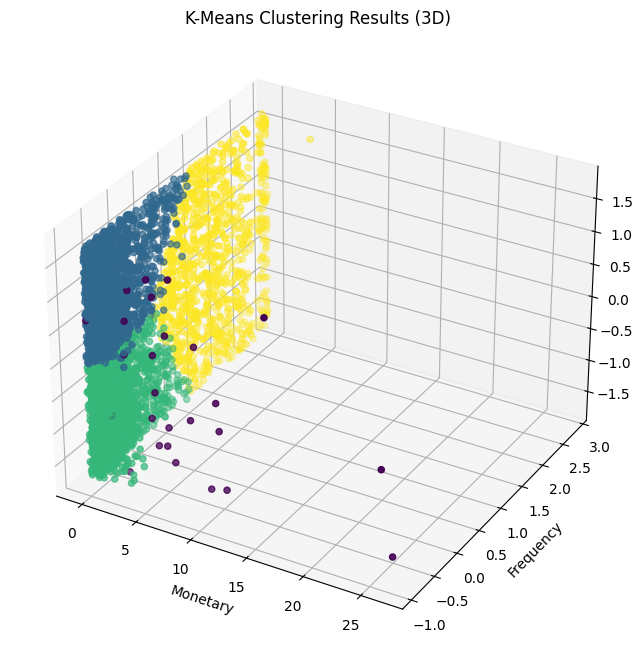

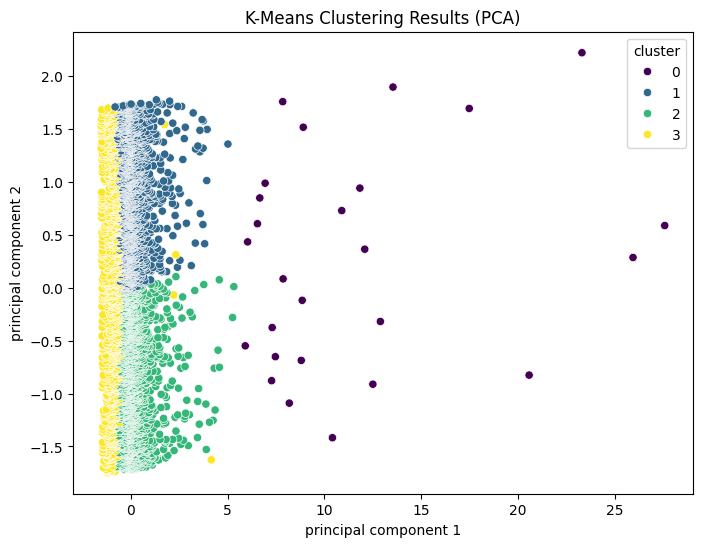

In [65]:
labels_rfm, kmeans_rfm = perform_kmeans_clustering(rfm, n_clusters=4)

Silhouette Score: 0.41521793186482303
Calinski-Harabasz Score: 4090.8203475113824
Davies-Bouldin Score: 0.8901213817607687
Dunn Index: 0.0062009455746722345


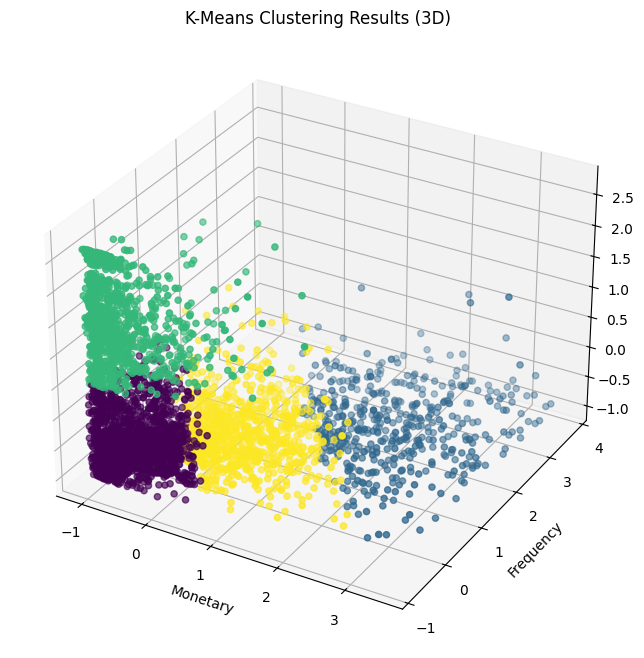

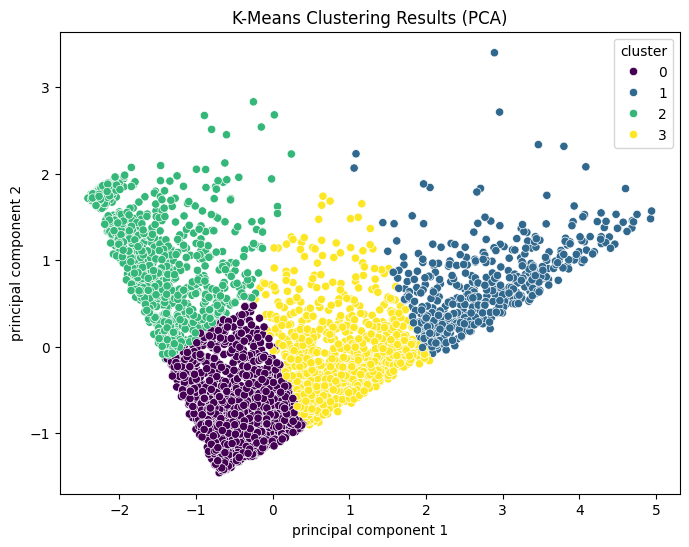

In [66]:
labels_non_outliers_df, kmeans_non_outliers_df = perform_kmeans_clustering(non_outliers_df, n_clusters=4)

Silhouette Score: 0.3287144393420125
Calinski-Harabasz Score: 2816.928905401757
Davies-Bouldin Score: 1.0183932767221473
Dunn Index: 0.0032545142376569362


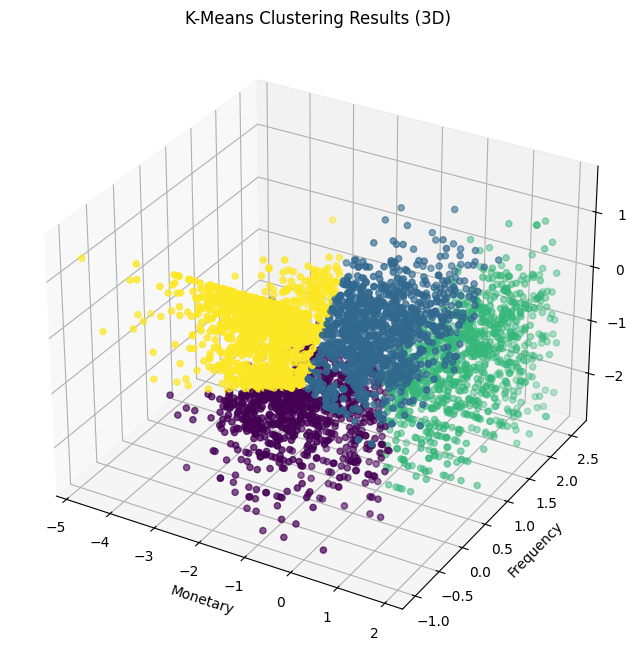

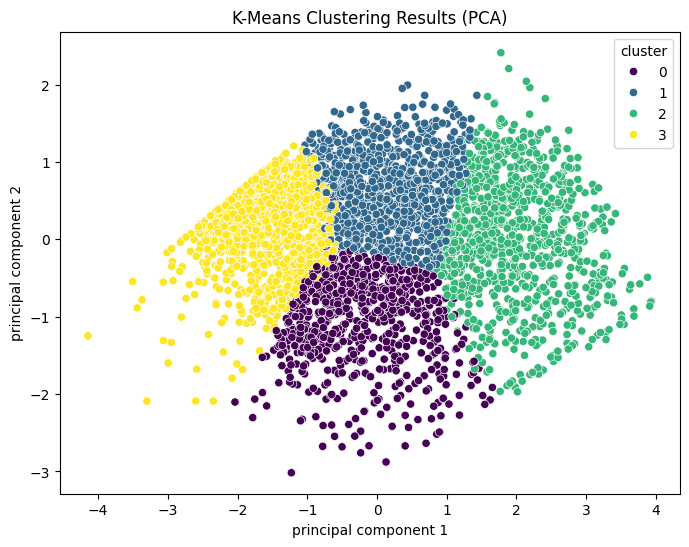

In [67]:
labels_2, kmeans_non_outliers_df_log = perform_kmeans_clustering(non_outliers_df_log, 4)

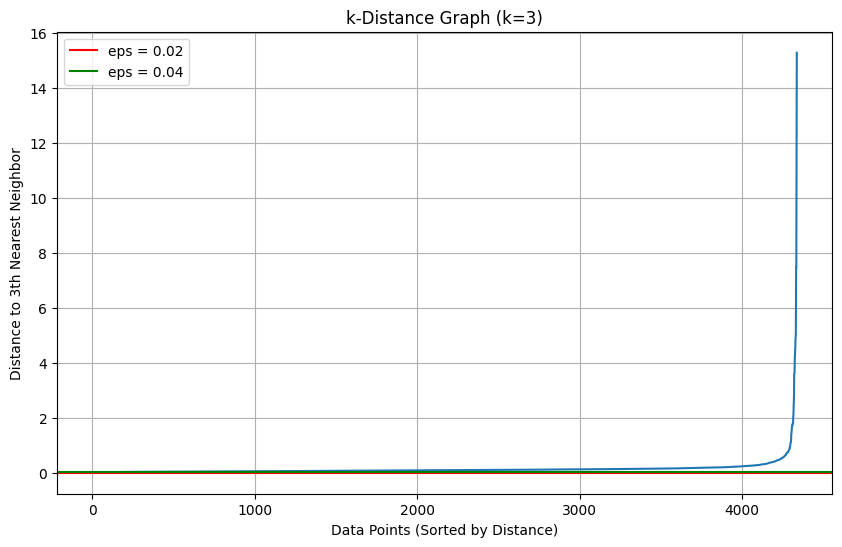

In [68]:
def plot_k_distance(data, k):
    """
    Plots the k-distance graph to help determine the optimal eps for DBSCAN.

    Args:
        data: The input DataFrame or array for clustering.
        k: The number of neighbors to consider.
    """
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # Sort distances
    distances = np.sort(distances[:, k-1], axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.title(f'k-Distance Graph (k={k})')
    plt.xlabel('Data Points (Sorted by Distance)')
    plt.ylabel(f'Distance to {k}th Nearest Neighbor')
    plt.grid(True)

    # Add vertical lines at y=0.02 and y=0.1
    plt.axhline(y=0.02, color='r', linestyle='-', label='eps = 0.02')
    plt.axhline(y=0.04, color='g', linestyle='-', label='eps = 0.04')
    plt.legend()

    plt.show()

# Example usage (replace non_outliers_df_log with your data and choose a suitable k)
# A common starting point for k is 2 * number of dimensions, or simply a small value like 5
plot_k_distance(rfm, k=3)

Number of clusters: 21
Number of noise points: 3501
Silhouette Score (excluding noise): 0.48472140922731305
Calinski-Harabasz Score (excluding noise): 6755.0143389542445
Davies-Bouldin Score (excluding noise): 0.5032200639002963


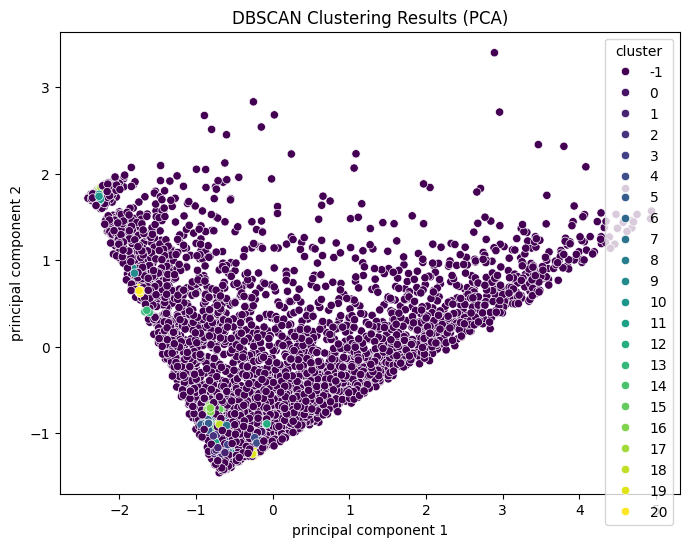

In [69]:
def perform_dbscan_clustering(data, eps, min_samples):
    """
    Performs DBSCAN clustering, evaluates the model, and visualizes the results.

    Args:
        data: The input DataFrame or array for clustering.
        eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
        min_samples: The number of samples in a neighborhood for a point to be considered as a core point.

    Returns:
        None (prints evaluation scores and plots the visualization).
    """
    # Build DBSCAN model
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(data)

    # Evaluate the model
    # Note: Silhouette, Calinski-Harabasz, and Davies-Bouldin scores are not suitable for models with noise points (label -1)
    # We can calculate these scores on the data excluding the noise points.
    # However, for a more comprehensive evaluation, consider metrics like V-measure or Adjusted Rand Index if ground truth labels are available.

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise}")

    if n_clusters > 1:
        # Exclude noise points for evaluation metrics that require at least two clusters
        core_samples_mask = np.zeros_like(labels, dtype=bool)
        core_samples_mask[dbscan.core_sample_indices_] = True
        non_noise_indices = labels != -1

        if np.sum(non_noise_indices) > 1:
            silhouette = silhouette_score(data[non_noise_indices], labels[non_noise_indices])
            calinski = calinski_harabasz_score(data[non_noise_indices], labels[non_noise_indices])
            davies = davies_bouldin_score(data[non_noise_indices], labels[non_noise_indices])

            print(f"Silhouette Score (excluding noise): {silhouette}")
            print(f"Calinski-Harabasz Score (excluding noise): {calinski}")
            print(f"Davies-Bouldin Score (excluding noise): {davies}")
        else:
            print("Cannot compute evaluation scores: Not enough non-noise points for evaluation.")
    else:
        print("Cannot compute evaluation scores: Only one cluster or all points are noise.")


    # Visualize the clusters using PCA
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(data)
    pca_df = pd.DataFrame(data = principal_components, columns = ['principal component 1', 'principal component 2'])
    pca_df['cluster'] = labels

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='principal component 1', y='principal component 2', hue='cluster', data=pca_df, palette='viridis', legend='full')
    plt.title('DBSCAN Clustering Results (PCA)')
    plt.show()
    return labels, dbscan

# Example usage (replace non_outliers_df_log with your data)
# You might need to adjust min_samples based on your data
labels_dbscan, dbscan = perform_dbscan_clustering(non_outliers_df, eps=0.04, min_samples=10)




In [71]:
non_outliers_data['Cluster'] = labels_non_outliers_df
non_outliers_data = non_outliers_data.sort_values(by = 'CustomerID')
non_outliers_data

,CustomerID,Recency,Frequency,Monetary,Cluster
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,3
4,12350.0,310,1,334.40,2
5,12352.0,36,8,2506.04,1
6,12353.0,204,1,89.00,2
...,...,...,...,...,...
4332,18278.0,74,1,173.90,0
4333,18280.0,278,1,180.60,2
4334,18281.0,181,1,80.82,2
4335,18282.0,8,2,178.05,0


In [72]:
def plot_rfm_clusters_2d(data):
    plt.figure(figsize=(10, 6))

    colors = ['red', 'blue', 'green', 'yellow', 'purple']

    for cluster in sorted(data['Cluster'].unique()):
        cluster_data = data[data['Cluster'] == cluster]
        plt.scatter(cluster_data['Recency'],
                    cluster_data['Frequency'],
                    c=colors[cluster],
                    label=f'Cluster {cluster}',
                    alpha=0.6)

    plt.xlabel('Recency')
    plt.ylabel('Frequency')
    plt.title('Customer Segments in 2D RFM Space')
    plt.legend()
    plt.show()

def plot_rfm_clusters_3d(data):
    # Create 3D scatter plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create color map for clusters
    colors = ['red', 'blue', 'green', 'yellow','purple']

    # Plot each cluster
    for cluster in sorted(data['Cluster'].unique()):
        cluster_data = data[data['Cluster'] == cluster]
        ax.scatter(cluster_data['Monetary'],
                cluster_data['Frequency'],
                cluster_data['Recency'],
                c=colors[cluster],
                label=f'Cluster {cluster}',
                alpha=0.6)

    # Customize the plot
    ax.set_xlabel('Monetary')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Recency')
    ax.set_title('Customer Segments in 3D RFM Space')
    plt.legend()
    plt.show()

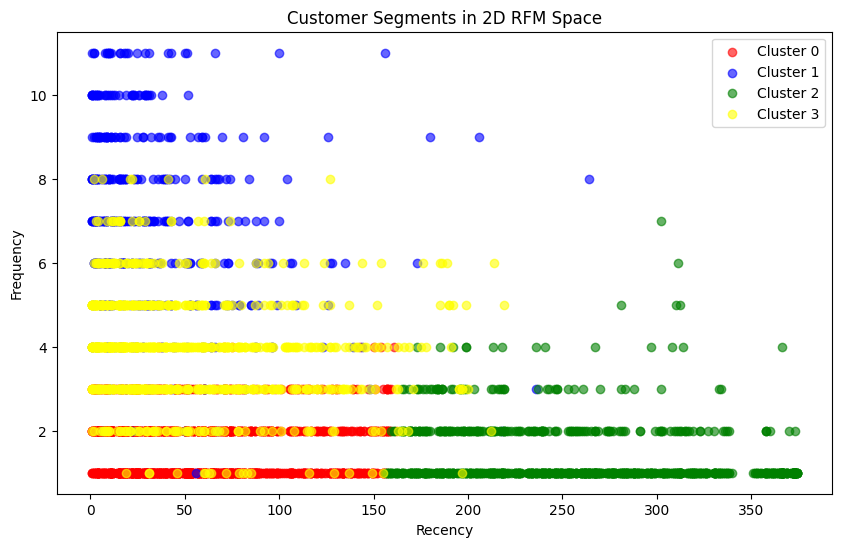

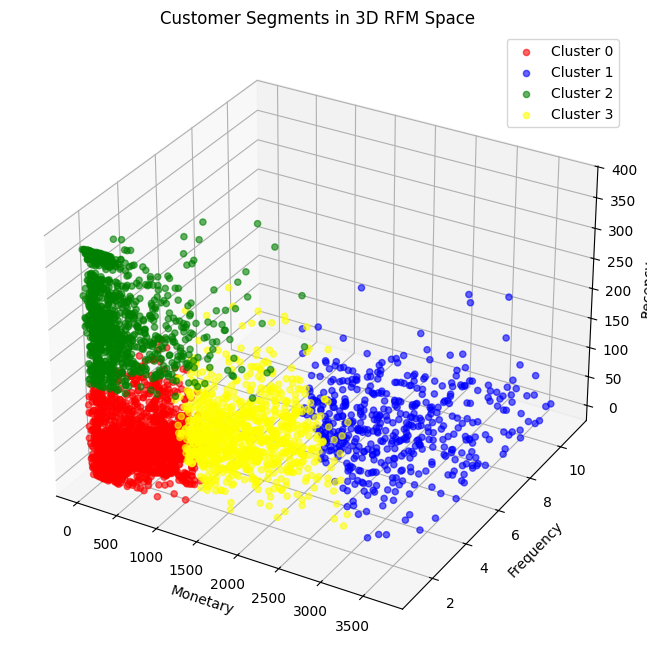

In [73]:
plot_rfm_clusters_2d(non_outliers_data)
plot_rfm_clusters_3d(non_outliers_data)

In [74]:
overlap_index = m_outliers.index.intersection(f_outliers.index)

m_o_outliers = m_outliers.drop(overlap_index)
f_o_outliers = f_outliers.drop(overlap_index)
mf_o_outliers = m_outliers.loc[overlap_index]

In [75]:
m_o_outliers['Cluster'] =  -3
f_o_outliers['Cluster'] = -2
mf_o_outliers['Cluster'] = -1

In [76]:
outliers_data = pd.concat([m_o_outliers, f_o_outliers, mf_o_outliers])
outliers_data

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,-3
1,12347.0,2,7,4310.00,-3
10,12357.0,33,1,6207.67,-3
12,12359.0,58,4,6372.58,-3
15,12362.0,3,10,5226.23,-3
...,...,...,...,...,...
4252,18172.0,15,20,7561.68,-1
4272,18198.0,4,17,5425.56,-1
4291,18223.0,5,14,6484.54,-1
4293,18225.0,3,12,5509.12,-1


In [77]:
rfm_non_outliers = pd.concat([non_outliers_data, outliers_data])
rfm_non_outliers

,CustomerID,Recency,Frequency,Monetary,Cluster
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,3
4,12350.0,310,1,334.40,2
5,12352.0,36,8,2506.04,1
6,12353.0,204,1,89.00,2
...,...,...,...,...,...
4252,18172.0,15,20,7561.68,-1
4272,18198.0,4,17,5425.56,-1
4291,18223.0,5,14,6484.54,-1
4293,18225.0,3,12,5509.12,-1


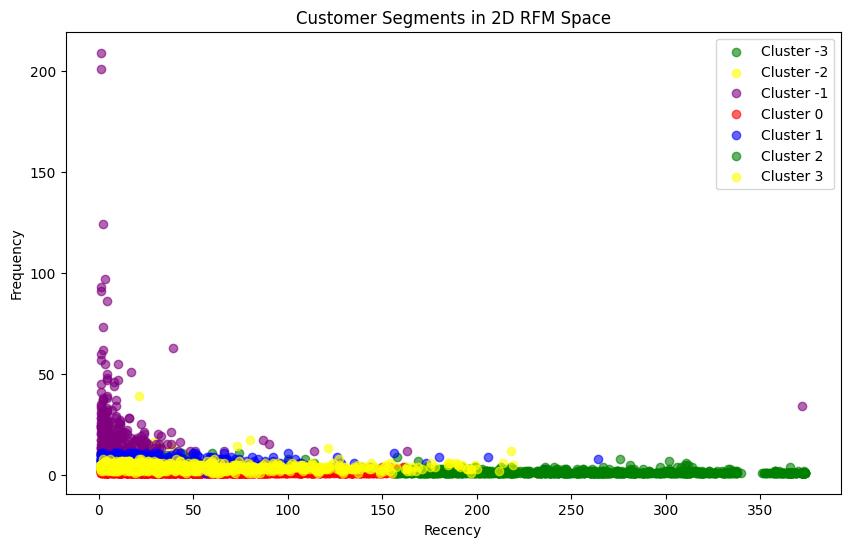

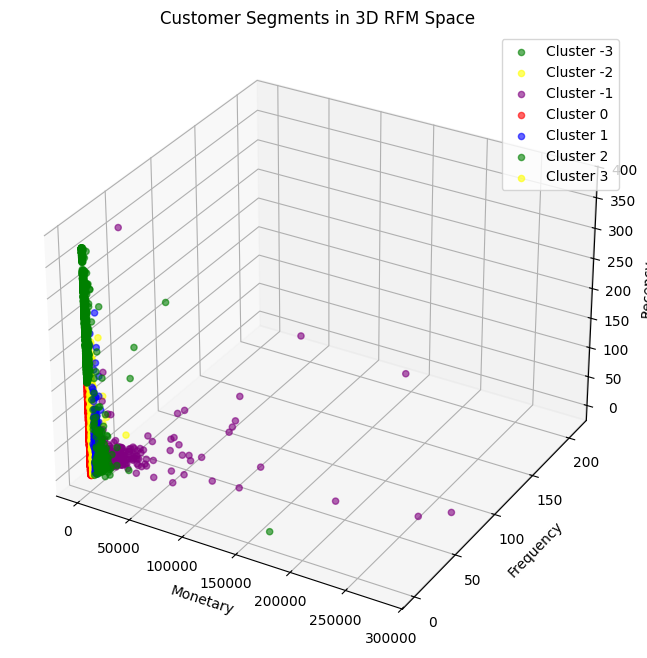

In [78]:
plot_rfm_clusters_2d(rfm_non_outliers)

plot_rfm_clusters_3d(rfm_non_outliers)


In [79]:
# divide rfm into 4 quarter to set the scorre
r_quarters = rfm_non_outliers['Recency'].quantile([0, 0.25, 0.5, 0.75, 1]).to_list()
f_quarters = rfm_non_outliers['Frequency'].quantile([0, 0.25, 0.5, 0.75, 1]).to_list()
m_quarters = rfm_non_outliers['Monetary'].quantile([0, 0.25, 0.5, 0.75, 1]).to_list()

In [80]:
quartile_spread = pd.DataFrame(
    list(zip(r_quarters, f_quarters, m_quarters)),
    columns=['R_Recency', 'F_Frequency', 'M_Monetary'],
    index=['min', 'Q1', 'Q2', 'Q3', 'max']
)
print(quartile_spread)
# F frequency có Q1 = min -> sẽ không chia được thành 4 (có thể loại bỏ duplicate rồi chia đươc bao nhiêu thì chia)

     R_Recency  F_Frequency  M_Monetary
min        1.0          1.0       3.750
Q1        18.0          1.0     307.415
Q2        51.0          2.0     674.485
Q3       142.0          5.0    1661.740
max      374.0        209.0  280206.020


In [81]:
f_quarters = pd.Series(f_quarters).drop_duplicates().to_list()

In [82]:
rfm_non_outliers['f_score'] = pd.cut(
    rfm_non_outliers['Frequency'],
    bins=f_quarters,
    labels=range(1, len(f_quarters)),
    include_lowest=True
)

In [83]:
rfm_non_outliers['r_score'] = pd.cut(rfm_non_outliers['Recency'], bins=r_quarters, labels=[4,3,2,1], include_lowest=True, duplicates='drop')

rfm_non_outliers['m_score'] = pd.cut(rfm_non_outliers['Monetary'], bins=m_quarters, labels=[1,2,3,4], include_lowest=True, duplicates='drop')
rfm_non_outliers['RFM_Score'] = rfm_non_outliers['r_score'].astype(str) + rfm_non_outliers['f_score'].astype(str) + rfm_non_outliers['m_score'].astype(str)

rfm_non_outliers['RFM_Score'].unique()

array(['224', '314', '112', '334', '111', '113', '324', '413', '212',
       '423', '411', '223', '313', '412', '213', '424', '124', '312',
       '434', '114', '122', '323', '311', '414', '214', '234', '433',
       '211', '322', '222', '333', '422', '133', '221', '321', '421',
       '233', '123', '121', '132', '432', '431', '134', '232', '131'],
      dtype=object)

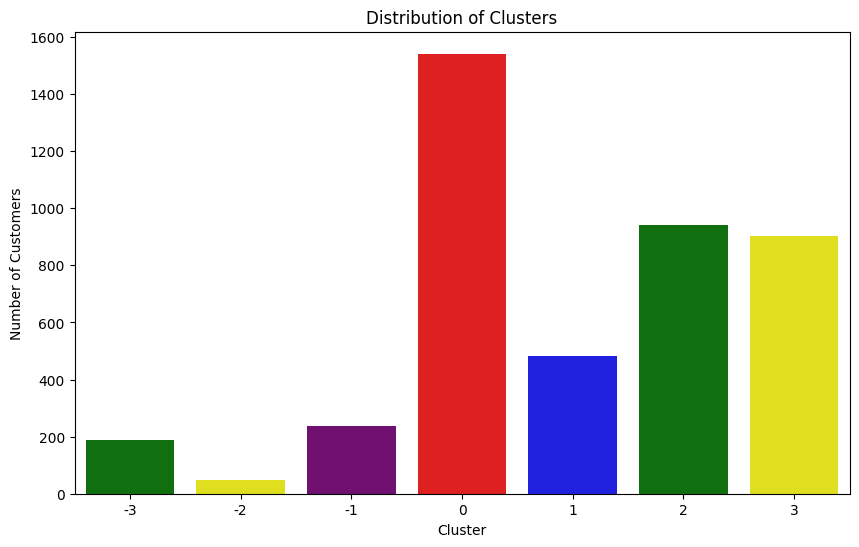

In [84]:
cluster_sizes = rfm_non_outliers['Cluster'].value_counts()
color1 = ['green', 'yellow', 'purple','red', 'blue', ]

plt.figure(figsize = (10,6))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette = color1)
plt.title('Distribution of Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

# Add value labels on top of each bar
# for i, v in enumerate(cluster_sizes.values):
#     plt.text(i, v, str(v), ha='center', va='bottom')
# plt.show()

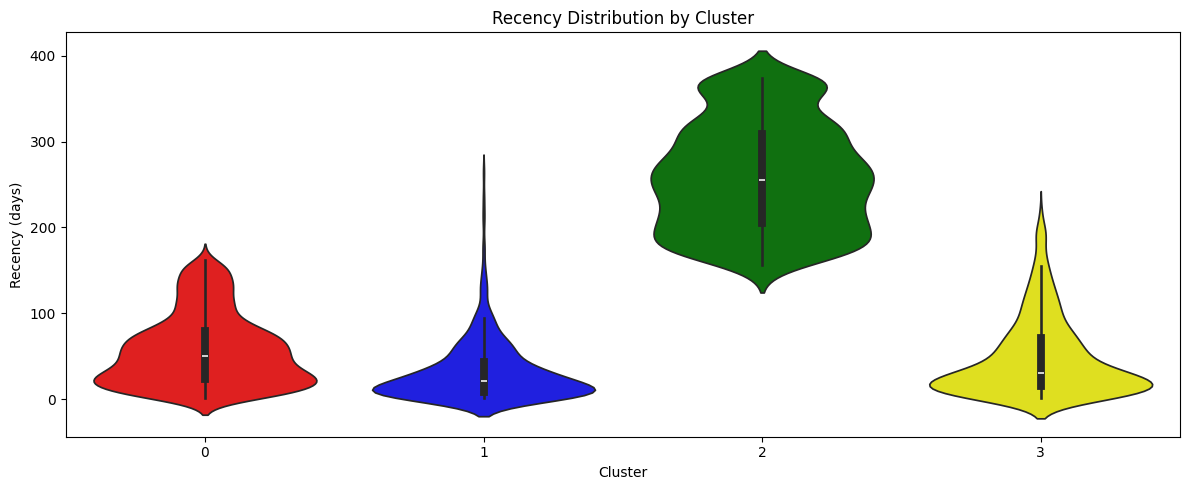

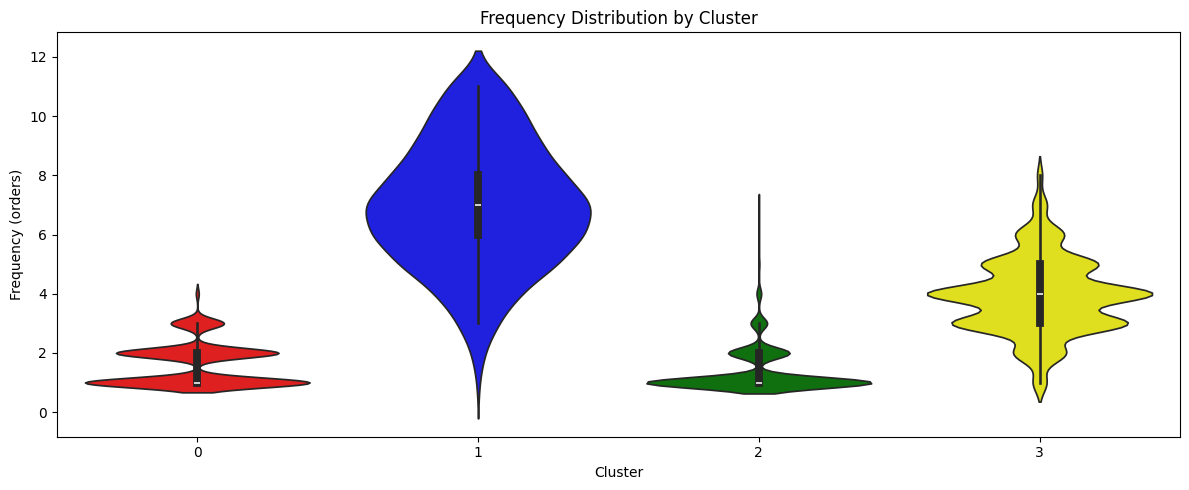

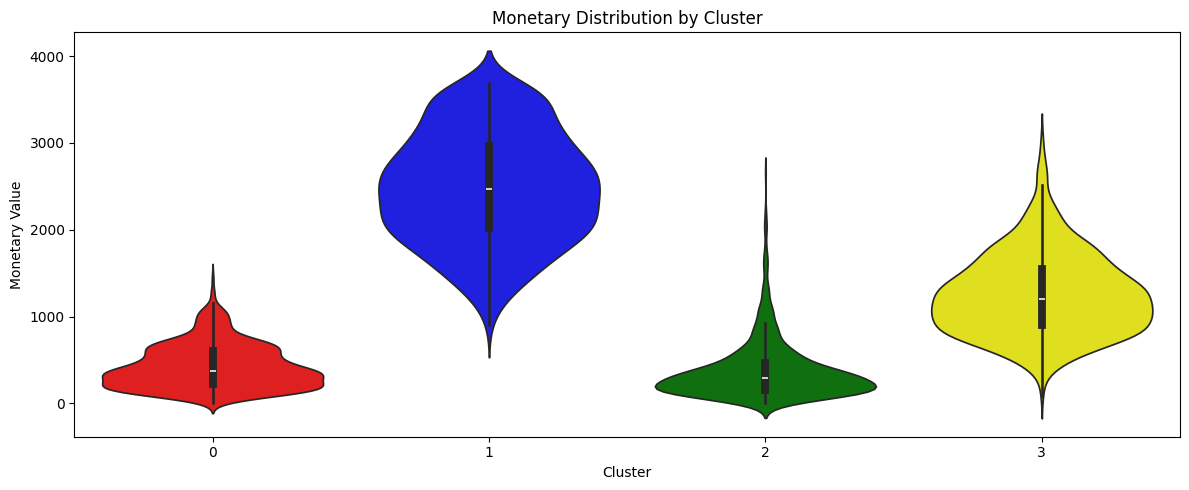

In [85]:
def plot_non_out_violin(data):
    # fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 10))

    # Plot Recency
    plt.figure(figsize = (12,5))
    sns.violinplot(x='Cluster', y='Recency', data=data, palette = ['red', 'blue', 'green', 'yellow','purple' ])
    plt.title('Recency Distribution by Cluster')
    plt.ylabel('Recency (days)')
    plt.tight_layout()
    plt.show()

    # Plot Frequency
    plt.figure(figsize = (12,5))
    sns.violinplot(x='Cluster', y='Frequency', data=data, palette = ['red', 'blue', 'green', 'yellow','purple' ])
    plt.title('Frequency Distribution by Cluster')
    plt.ylabel('Frequency (orders)')
    plt.tight_layout()
    plt.show()

    # Plot Monetary
    plt.figure(figsize = (12,5))
    sns.violinplot(x='Cluster', y='Monetary', data=data, palette = ['red', 'blue', 'green', 'yellow','purple' ])
    plt.title('Monetary Distribution by Cluster')
    plt.ylabel('Monetary Value')

    plt.tight_layout()
    plt.show()

# Call the function with your data
plot_non_out_violin(non_outliers_data)


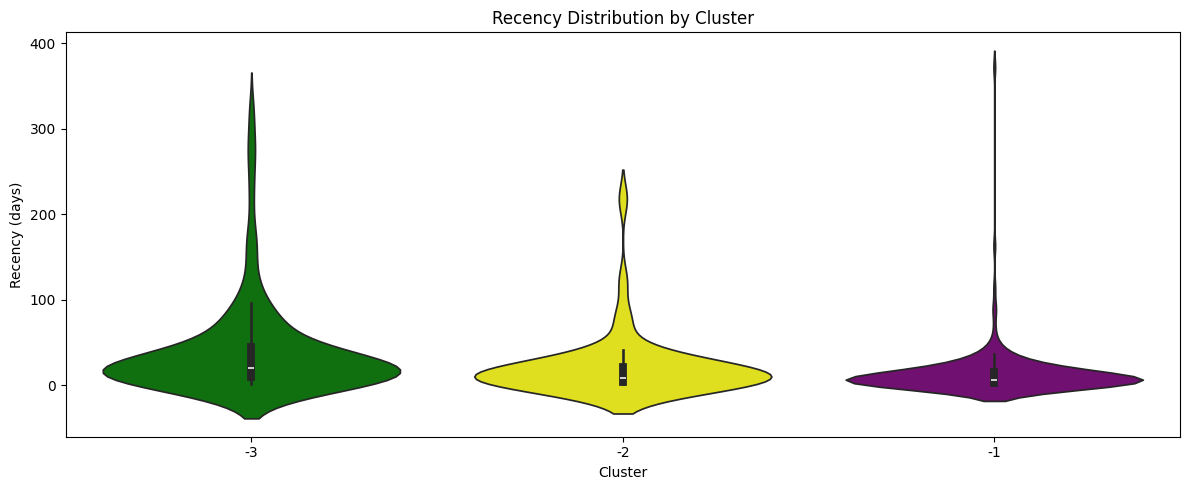

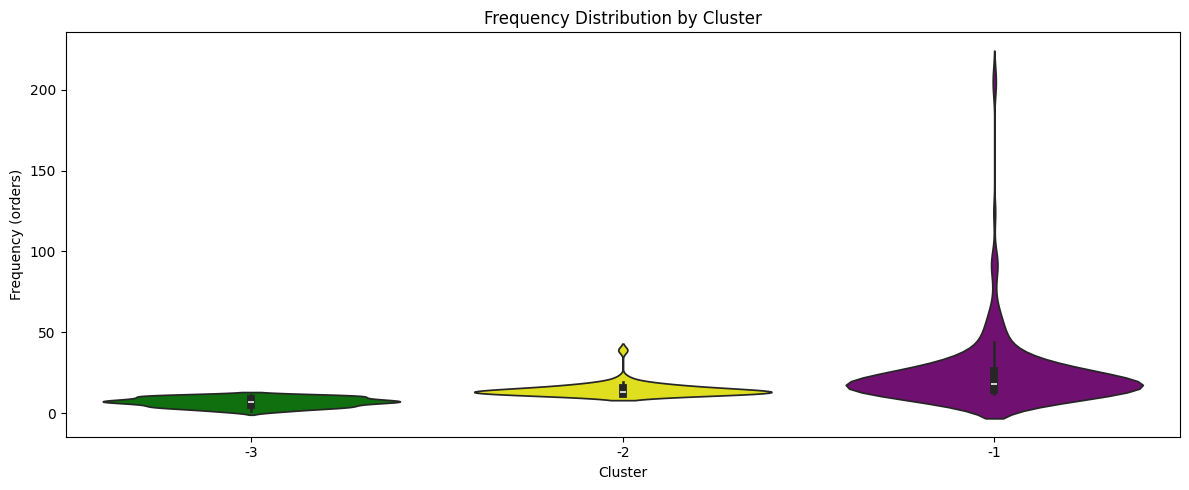

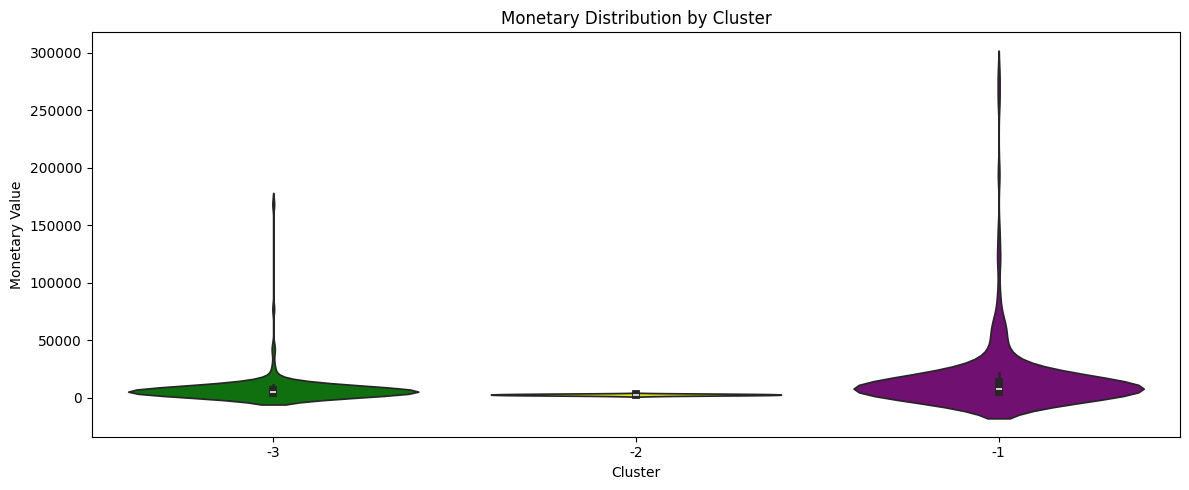

In [86]:
def plot_non_out_violin(data):
    # fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 10))

    # Plot Recency
    plt.figure(figsize = (12,5))
    sns.violinplot(x='Cluster', y='Recency', data=data, palette = ['green', 'yellow', 'purple'])
    plt.title('Recency Distribution by Cluster')
    plt.ylabel('Recency (days)')
    plt.tight_layout()
    plt.show()

    # Plot Frequency
    plt.figure(figsize = (12,5))
    sns.violinplot(x='Cluster', y='Frequency', data=data, palette = ['green', 'yellow', 'purple' ])
    plt.title('Frequency Distribution by Cluster')
    plt.ylabel('Frequency (orders)')
    plt.tight_layout()
    plt.show()

    # Plot Monetary
    plt.figure(figsize = (12,5))
    sns.violinplot(x='Cluster', y='Monetary', data=data, palette = ['green', 'yellow', 'purple' ])
    plt.title('Monetary Distribution by Cluster')
    plt.ylabel('Monetary Value')

    plt.tight_layout()
    plt.show()

# Call the function with your data
plot_non_out_violin(outliers_data)


In [87]:
cluster_summary_mean = rfm_non_outliers.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary_median = rfm_non_outliers.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].median()

print("Mean values for each cluster:")
display(cluster_summary_mean)

print("\nMedian values for each cluster:")
display(cluster_summary_median)

Mean values for each cluster:


,Recency,Frequency,Monetary
Cluster,,,
-3,40.269841,6.857143,7535.036984
-2,21.510638,14.595745,2646.785957
-1,13.273109,24.605042,16888.991681
0,56.924724,1.626217,426.745945
1,32.244813,6.958506,2484.088280
2,258.905319,1.373404,379.391234
3,47.733629,3.932297,1256.085617



Median values for each cluster:


,Recency,Frequency,Monetary
Cluster,,,
-3,20.0,7.0,4939.990
-2,8.0,13.0,2622.570
-1,5.5,18.0,7318.000
0,50.0,1.0,377.010
1,21.0,7.0,2474.280
2,255.0,1.0,298.295
3,31.0,4.0,1201.060


In [99]:
cluster_names = {
    -1: 'Valuable Customers (Outliers)',
    -2: 'Frequent Buyers (Outliers)',
    -3: 'High-Spending Buyers (Outliers)',
    0: 'New/Single Purchase Customers',
    1: 'Engaged Customers',
    2: 'At Risk Customers',
    3: 'Moderate Engagement Customers'
}

rfm_non_outliers['Segment'] = rfm_non_outliers['Cluster'].map(cluster_names)

display(rfm_non_outliers.head())

,CustomerID,Recency,Frequency,Monetary,Cluster,f_score,r_score,m_score,RFM_Score,Segment
2,12348.0,75,4,1797.24,3,2,2,4,224,Moderate Engagement Customers
3,12349.0,19,1,1757.55,3,1,3,4,314,Moderate Engagement Customers
4,12350.0,310,1,334.40,2,1,1,2,112,At Risk Customers
5,12352.0,36,8,2506.04,1,3,3,4,334,Engaged Customers
6,12353.0,204,1,89.00,2,1,1,1,111,At Risk Customers


In [100]:
rfm_non_outliers

,CustomerID,Recency,Frequency,Monetary,Cluster,f_score,r_score,m_score,RFM_Score,Segment
2,12348.0,75,4,1797.24,3,2,2,4,224,Moderate Engagement Customers
3,12349.0,19,1,1757.55,3,1,3,4,314,Moderate Engagement Customers
4,12350.0,310,1,334.40,2,1,1,2,112,At Risk Customers
5,12352.0,36,8,2506.04,1,3,3,4,334,Engaged Customers
6,12353.0,204,1,89.00,2,1,1,1,111,At Risk Customers
...,...,...,...,...,...,...,...,...,...,...
4252,18172.0,15,20,7561.68,-1,3,4,4,434,Valuable Customers (Outliers)
4272,18198.0,4,17,5425.56,-1,3,4,4,434,Valuable Customers (Outliers)
4291,18223.0,5,14,6484.54,-1,3,4,4,434,Valuable Customers (Outliers)
4293,18225.0,3,12,5509.12,-1,3,4,4,434,Valuable Customers (Outliers)


In [106]:
def xgb_function(data):
  xgb_df = data.copy()

  le = LabelEncoder()
  xgb_df['Segment'] = le.fit_transform(xgb_df['Segment'])

  X_xgb = xgb_df.drop(columns=['Cluster', 'CustomerID', 'Segment'])
  y_xgb = xgb_df['Segment']

  X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

  scaler = StandardScaler()
  X_xgb_train = scaler.fit_transform(X_xgb_train)
  X_xgb_test = scaler.transform(X_xgb_test)

  return X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test, scaler

X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test, scaler_xgb = xgb_function(rfm_non_outliers)

In [107]:
def classifier_model(model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print("Model name:", type(model).__name__)
  print(classification_report(y_test, y_pred))
  # print('Confusion_matrix:', confusion_matrix(y, y_pred))
  return model

In [108]:
#knn use function
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model = classifier_model(knn_model, X_xgb_train, y_xgb_train, X_xgb_test, y_xgb_test)

#logi
logi_model = LogisticRegression(random_state=42)
logi_model = classifier_model(logi_model, X_xgb_train, y_xgb_train, X_xgb_test, y_xgb_test)

#decision tree
dt_model = DecisionTreeClassifier()
dt_model = classifier_model(dt_model, X_xgb_train, y_xgb_train, X_xgb_test, y_xgb_test)

#random forest
rdf_model = RandomForestClassifier()
rdf_model = classifier_model(rdf_model, X_xgb_train, y_xgb_train, X_xgb_test, y_xgb_test)

#xgboost
xgb_model = XGBClassifier()
xgb_model = classifier_model(xgb_model, X_xgb_train, y_xgb_train, X_xgb_test, y_xgb_test)

Model name: KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       177
           1       0.79      0.88      0.83       104
           2       0.60      0.43      0.50         7
           3       0.94      0.64      0.76        47
           4       0.90      0.92      0.91       170
           5       0.97      0.98      0.97       308
           6       0.93      0.93      0.93        55

    accuracy                           0.93       868
   macro avg       0.87      0.82      0.84       868
weighted avg       0.93      0.93      0.93       868

Model name: LogisticRegression
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       177
           1       0.79      0.70      0.74       104
           2       1.00      0.29      0.44         7
           3       0.94      0.64      0.76        47
           4       0.79      0.85      0.82       170
           5  

In [110]:
#save model
save_model(xgb_model, 'xgb_classifier_model.pkl')
save_model(scaler_xgb, 'xgb_scaler.pkl')

Model successfully saved to xgb_classifier_model.pkl
Model successfully saved to xgb_scaler.pkl
